In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r'C:\Users\apaks\Desktop\Real Estate Project\artifacts\data\preprocessed-data\gurgaon_properties_post_feature_selection.csv')

In [3]:
df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 83,1.18,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise
1,flat,sector 62,4.00,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise
2,flat,sector 85,1.10,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise
3,flat,sector 91,0.89,2,2,3+,relatively new,1297.0,0,0,semifurnished,budget,medium-rise
4,flat,sector 7,0.48,3,2,1,new,889.0,0,0,unfurnished,budget,low-rise


In [4]:
X = df.drop(columns = 'price')
y = df['price']

<Axes: xlabel='price', ylabel='Count'>

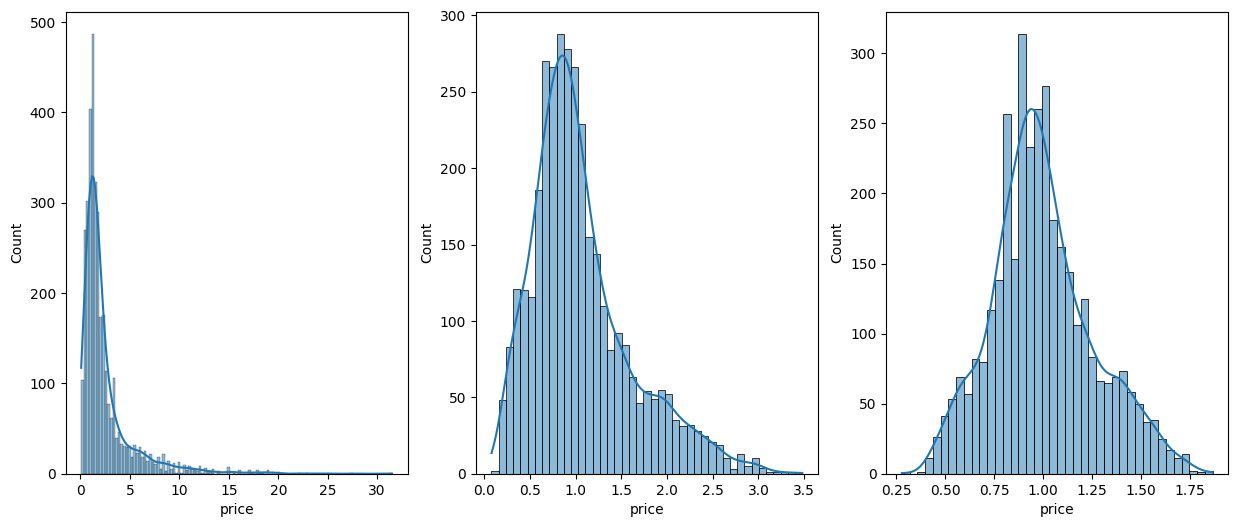

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# check price distribution for transformation
plt.figure(figsize=(15, 6))
plt.subplot(1,3,1)
sns.histplot(y, kde = True)

plt.subplot(1,3,2)
sns.histplot(np.log1p(y), kde = True)

plt.subplot(1,3,3)
sns.histplot(np.sqrt(np.log1p(y)), kde = True)



### Ordinal encoding

In [6]:
X.columns

Index(['property_type', 'sector', 'bedRoom', 'bathroom', 'balcony',
       'agePossession', 'built_up_area', 'servant room', 'store room',
       'furnishing_type', 'luxury_category', 'floor_category'],
      dtype='str')

In [7]:
cat_columns = ['property_type', 'sector', 'balcony', 'agePossession', 'furnishing_type','luxury_category', 'floor_category']
num_columns = ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from category_encoders import TargetEncoder

In [9]:
preprocessor = ColumnTransformer([
    ('cat_columns', OrdinalEncoder(), cat_columns),
    ('num_columns', StandardScaler(),num_columns)
])

In [10]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [11]:
# apply LR model to X, y/log(y), sqrt(log(y)) and calculate cross val scores

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error

kfold = KFold(n_splits=10, shuffle= True, random_state=42)
scores_normal = cross_val_score(pipeline, X, y, scoring = 'r2', cv = kfold, n_jobs=-1, verbose=1)

scores_log_y = cross_val_score(pipeline, X, np.log1p(y), scoring = 'r2', cv = kfold, n_jobs=-1, verbose=1)

scores_sqrt_log_y = cross_val_score(pipeline, X, np.sqrt(np.log1p(y)), scoring = 'r2', cv = kfold, n_jobs=-1, verbose=1)

print('score_normal', scores_normal.mean(), scores_normal.std())
print('score_log_y', scores_log_y.mean(), scores_log_y.std())
print('scores_sqrt_log_y', scores_sqrt_log_y.mean(), scores_sqrt_log_y.std())



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:   12.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.


score_normal 0.6749410534132549 0.028698320794748187
score_log_y 0.7386926129586253 0.022956191703965328
scores_sqrt_log_y 0.710284770481906 0.021569674612447506


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.1s finished


- log1p(y) has improved scores

In [12]:
# transform y

y_transformed = np.log1p(y)

<Axes: xlabel='built_up_area', ylabel='Count'>

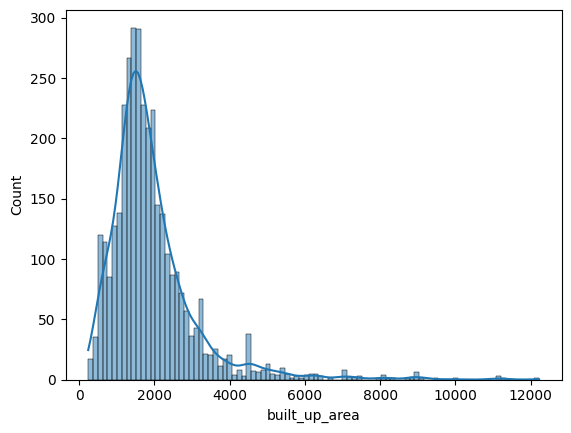

In [13]:
sns.histplot(df['built_up_area'], kde = True)

<Axes: xlabel='built_up_area', ylabel='Count'>

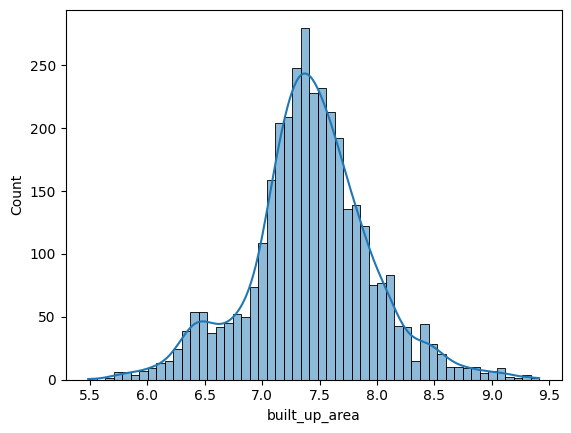

In [14]:
# transform builtup area as well as it is also skewed

sns.histplot(X['built_up_area'].apply(lambda x : (np.log1p(x))), kde = True)

In [15]:
X_temp = X.copy()

In [16]:
X_temp['built_up_area'] = (np.log1p(df['built_up_area'])**2)

In [17]:
# apply lr on data with log1p(y) and log1p(built_up_area)

kfold = KFold(n_splits=10, shuffle= True, random_state=42)

scores = cross_val_score(pipeline, X_temp, y_transformed, scoring = 'r2', cv = kfold, n_jobs=-1, verbose=4)

print('scores', scores.mean(), scores.std())


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done   6 out of  10 | elapsed:    0.1s remaining:    0.0s


scores 0.7429491768404615 0.017002476783249277


[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.1s finished


- improved results with this transformation (np.log1p(df['built_up_area'])**2)

In [18]:
X['built_up_area'] = (np.log1p(df['built_up_area'])**2)

In [19]:
# calculate mean absolute error
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

In [20]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))
print(mae)

0.8301483200899098


- MAE is also improved after transforming builtup area

In [21]:
# function to evaluate cv_r2 and mae 

def scorer(model_name, model):

    output = []

    model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', model)
    ])

    # cross val score on complete dataset
    kfold = KFold(n_splits=10, shuffle= True, random_state=42)
    scores = cross_val_score(model_pipeline, X, y_transformed, scoring = 'r2', cv = kfold, n_jobs=-1)

    output.append(model_name)
    output.append(scores.mean())

    # train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state=42)

    # fit the model on train set 
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)

    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

    output.append(mae)
    # print(output)
    return output



In [22]:
print(scorer('LinearRegression', LinearRegression()))

['LinearRegression', np.float64(0.7429491768404615), 0.8301483200899098]


Try different models with no tunning

In [23]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [24]:
model_dict = {
    'linear_regression' : LinearRegression(),
    'ridge': Ridge(),
    'lasso': Lasso(),
    'svr': SVR(),
    'decision_tree': DecisionTreeRegressor(),
    'extra_tree_regressor': ExtraTreeRegressor(),
    'random_forrest': RandomForestRegressor(),
    'gradient_boosting': GradientBoostingRegressor(),
    'ada_boost': AdaBoostRegressor(),
    'xgb_regressor': XGBRegressor(),
    'mlp': MLPRegressor()
}

In [25]:
model_outputs = []

for model_name, model in model_dict.items():
    model_outputs.append(scorer(model_name, model))
    print(model_name, 'completed')

linear_regression completed
ridge completed
lasso completed
svr completed
decision_tree completed
extra_tree_regressor completed
random_forrest completed
gradient_boosting completed
ada_boost completed
xgb_regressor completed
mlp completed


In [26]:
ordinal_encoding_model_outputs = pd.DataFrame(model_outputs, columns = ['model_name', 'cv_r2', 'mae'])

In [27]:
ordinal_encoding_model_outputs.sort_values('mae', ascending=True)

,model_name,cv_r2,mae
9,xgb_regressor,0.902986,0.519913
6,random_forrest,0.890019,0.531569
7,gradient_boosting,0.874658,0.597672
4,decision_tree,0.798616,0.679229
10,mlp,0.816831,0.695732
5,extra_tree_regressor,0.722518,0.813620
0,linear_regression,0.742949,0.830148
1,ridge,0.742954,0.830411
8,ada_boost,0.754941,0.835426
3,svr,0.759846,0.852453


In [28]:
# lets try all the models without transforming built_up_area

X['built_up_area'] = df['built_up_area']

model_outputs = []

for model_name, model in model_dict.items():
    model_outputs.append(scorer(model_name, model))
    print(model_name, 'completed')

linear_regression completed
ridge completed
lasso completed
svr completed
decision_tree completed
extra_tree_regressor completed
random_forrest completed
gradient_boosting completed
ada_boost completed
xgb_regressor completed
mlp completed


In [29]:
ordinal_encoding_model_outputs = pd.DataFrame(model_outputs, columns = ['model_name', 'cv_r2', 'mae'])
ordinal_encoding_model_outputs.sort_values('mae', ascending=True)

,model_name,cv_r2,mae
9,xgb_regressor,0.902986,0.519913
6,random_forrest,0.891273,0.534463
7,gradient_boosting,0.874643,0.598646
10,mlp,0.804823,0.697673
4,decision_tree,0.797687,0.707278
8,ada_boost,0.756995,0.856642
3,svr,0.765729,0.862447
5,extra_tree_regressor,0.737175,0.885585
0,linear_regression,0.741415,0.919793
1,ridge,0.741419,0.919884


- mae in case of linear models was better when transformed built_up_area was used. But not much impact on tree based models as expected. 
- Best performing models are xgbregressor and random forest. 

One Hot Encoding

In [30]:
X.head(3)

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category
0,flat,sector 83,3,3,2,relatively new,1612.0,0,0,unfurnished,budget,high-rise
1,flat,sector 62,3,3,3,new,2353.0,1,0,semifurnished,budget,high-rise
2,flat,sector 85,2,2,3+,relatively new,1459.0,0,1,unfurnished,luxury,low-rise


In [31]:
cat_columns_ohe = ['agePossession', 'sector', 'furnishing_type']

cat_columns_ord = ['property_type', 'balcony', 'luxury_category', 'floor_category']

num_columns = ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']

In [32]:
preprocessor = ColumnTransformer([
    ('cat_ohe', OneHotEncoder(), cat_columns_ohe),
    ('cat_ord', OrdinalEncoder(), cat_columns_ord), 
    ('num_std', StandardScaler(), num_columns)
])

In [33]:
model_outputs = []

for model_name, model in model_dict.items():
    model_outputs.append(scorer(model_name, model))
    print(model_name, 'completed')

ohe_model_outputs = pd.DataFrame(model_outputs, columns = ['model_name', 'cv_r2', 'mae'])
ohe_model_outputs.sort_values('mae', ascending=True)

linear_regression completed
ridge completed
lasso completed
svr completed
decision_tree completed
extra_tree_regressor completed
random_forrest completed
gradient_boosting completed
ada_boost completed
xgb_regressor completed
mlp completed


,model_name,cv_r2,mae
9,xgb_regressor,0.900444,0.540948
3,svr,0.883115,0.545683
6,random_forrest,0.882664,0.559124
10,mlp,0.884507,0.561501
5,extra_tree_regressor,0.809696,0.613635
7,gradient_boosting,0.864304,0.627945
0,linear_regression,0.852727,0.666122
1,ridge,0.852893,0.666771
4,decision_tree,0.799836,0.678116
8,ada_boost,0.734388,0.891482


In [34]:
# applying both ordinal encoding and ohe to some of the columns 

cat_columns_ohe = ['property_type', 'sector', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']    
cat_columns_ord = ['sector', 'agePossession', 'furnishing_type'] 
num_columns = ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']

preprocessor = ColumnTransformer([
    ('cat_ohe', OneHotEncoder(), cat_columns_ohe),
    ('cat_ord', OrdinalEncoder(), cat_columns_ord), 
    ('num_std', StandardScaler(), num_columns)
])

model_outputs = []

for model_name, model in model_dict.items():
    model_outputs.append(scorer(model_name, model))
    print(model_name, 'completed')

ohe_model_outputs = pd.DataFrame(model_outputs, columns = ['model_name', 'cv_r2', 'mae'])
ohe_model_outputs.sort_values('mae', ascending=True)

linear_regression completed
ridge completed
lasso completed
svr completed
decision_tree completed
extra_tree_regressor completed
random_forrest completed
gradient_boosting completed
ada_boost completed
xgb_regressor completed
mlp completed


,model_name,cv_r2,mae
6,random_forrest,0.899068,0.493675
9,xgb_regressor,0.904077,0.532898
10,mlp,0.874715,0.543952
7,gradient_boosting,0.880372,0.581092
5,extra_tree_regressor,0.800701,0.645176
0,linear_regression,0.854354,0.660761
1,ridge,0.854204,0.662064
4,decision_tree,0.824268,0.667750
3,svr,0.784923,0.827779
8,ada_boost,0.766786,0.839852


- MAE is the lowest when some of the columns are encoded twice, first ordinal encoding and then one hot encoding. Random forest is giving the best mae. Tree based models are not impacted due to redundant features resulting from dual encoding
- Random Forest with best combination of cv_r2 and mean absolute error

Target Encoding

In [47]:
# sector column is only target encoded

def scorer_for_target_encoding(model_name, model):
    output = []
    
    X_train, X_test, y_train, y_test = train_test_split(X, y_transformed, test_size=0.2, random_state = 42)

    cat_columns_ohe = ['property_type', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']       #one hot encoding
    cat_columns_ord = ['agePossession', 'furnishing_type']  #ordinal encoding
    cat_columns_te = ['sector']     #target encoding
    num_columns = ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']

    preprocessor = ColumnTransformer([
    ('cat_ohe', OneHotEncoder(), cat_columns_ohe),
    ('cat_ord', OrdinalEncoder(), cat_columns_ord), 
    ('num_std', StandardScaler(), num_columns),
    ('cat_te', TargetEncoder(), cat_columns_te)
    ], remainder='passthrough')

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    kfold = KFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv = kfold, scoring = 'r2', n_jobs = -1)

    output.append(model_name)
    output.append(scores.mean())

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

    output.append(mae)

    return output

In [48]:
model_outputs = []

for model_name, model in model_dict.items():
    model_outputs.append(scorer_for_target_encoding(model_name, model))
    print(model_name, 'completed')

te_model_outputs = pd.DataFrame(model_outputs, columns = ['model_name', 'cv_r2', 'mae'])
te_model_outputs.sort_values('mae', ascending=True)

linear_regression completed
ridge completed
lasso completed
svr completed
decision_tree completed
extra_tree_regressor completed
random_forrest completed
gradient_boosting completed
ada_boost completed
xgb_regressor completed
mlp completed


,model_name,cv_r2,mae
6,random_forrest,0.892086,0.485145
9,xgb_regressor,0.895164,0.504948
7,gradient_boosting,0.882596,0.556346
3,svr,0.856940,0.587228
10,mlp,0.846569,0.608576
4,decision_tree,0.805480,0.612086
5,extra_tree_regressor,0.772254,0.719517
0,linear_regression,0.824535,0.723574
1,ridge,0.824570,0.723790
8,ada_boost,0.820013,0.726786


- Random forest with below encoding is giving the best combination of cv_r2 score and mean absolute error
    -   cat_columns_ohe = ['property_type', 'balcony', 'agePossession', 'furnishing_type', 'luxury_category', 'floor_category']       #one hot encoding
    -   cat_columns_ord = ['agePossession', 'furnishing_type']  #ordinal encoding
    -   cat_columns_te = ['sector']     #target encoding
    -   num_columns = ['bedRoom', 'bathroom', 'built_up_area', 'servant room', 'store room']